In [3]:
import pandas as pd

# Memuat data dari file CSV
file_path = 'Supermarket Sales Cleaned.csv'
df = pd.read_csv(file_path)

# Mendapatkan nilai unik dari 'City' dan 'Product line'
unique_cities = df['City'].unique()
unique_product_lines = df['Product line'].unique()

print("\nCity:", unique_cities)
print("\nProduct line:", unique_product_lines)


City: ['Yangon' 'Naypyitaw' 'Mandalay']

Product line: ['Health and beauty' 'Electronic accessories' 'Home and lifestyle'
 'Sports and travel' 'Food and beverages' 'Fashion accessories']


In [4]:
# Menghitung total kemunculan setiap product line berdasarkan kota
product_line_count = df.groupby(['City', 'Product line']).size().reset_index(name='Count')
print(product_line_count)

         City            Product line  Count
0    Mandalay  Electronic accessories     55
1    Mandalay     Fashion accessories     62
2    Mandalay      Food and beverages     50
3    Mandalay       Health and beauty     53
4    Mandalay      Home and lifestyle     50
5    Mandalay       Sports and travel     62
6   Naypyitaw  Electronic accessories     55
7   Naypyitaw     Fashion accessories     65
8   Naypyitaw      Food and beverages     66
9   Naypyitaw       Health and beauty     52
10  Naypyitaw      Home and lifestyle     45
11  Naypyitaw       Sports and travel     45
12     Yangon  Electronic accessories     60
13     Yangon     Fashion accessories     51
14     Yangon      Food and beverages     58
15     Yangon       Health and beauty     47
16     Yangon      Home and lifestyle     65
17     Yangon       Sports and travel     59


In [5]:
#!pip install pandas numpy matplotlib prince

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.8/417.8 kB 24.5 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import prince

In [8]:
data = {
    'Electronic accessories':[55,55,60],
    'Fashion accessories':[62,65,51],
    'Food and beverages':[50,66,58],
    'Health and beauty':[53,52,47],
    'Home and lifestyle':[50,45,65],
    'Sports and travel':[62,45,59]
}

#Nama kota sebagai index
kota = 'Mandalay', 'Naypyitaw', 'Yangon'

In [9]:
df = pd.DataFrame(data, index=kota)

# Menampilkan dataframe
print(df)

           Electronic accessories  Fashion accessories  Food and beverages  \
Mandalay                       55                   62                  50   
Naypyitaw                      55                   65                  66   
Yangon                         60                   51                  58   

           Health and beauty  Home and lifestyle  Sports and travel  
Mandalay                  53                  50                 62  
Naypyitaw                 52                  45                 45  
Yangon                    47                  65                 59  


In [10]:
#Analisis Korespondensi
ca = prince.CA(
    n_components=2,  # Menggunakan 2 komponen
    n_iter=3,        # Jumlah iterasi untuk konvergensi
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)
ca = ca.fit(df)

In [13]:
eigenvalues_summary = ca.eigenvalues_summary
print("\nEigenvalues Summary:")
print(eigenvalues_summary)


Eigenvalues Summary:
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.008        69.54%                     69.54%
1              0.004        30.46%                    100.00%


<ipython-input-22-8749dd7a58bf>:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (row_coords[0][i], row_coords[1][i]), color='orange')
<ipython-input-22-8749dd7a58bf>:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (col_coords[0][i], col_coords[1][i]), color='blue')


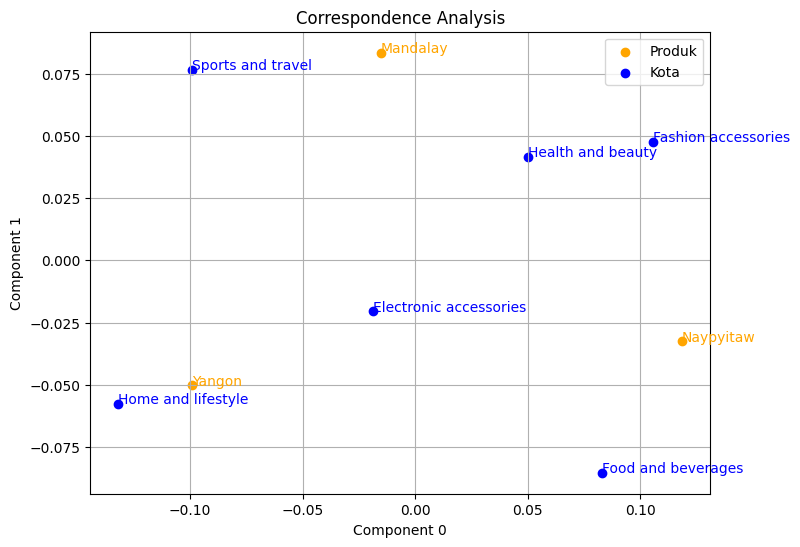

In [22]:
# Mengekstrak kordinat baris dan kolom
row_coords = ca.row_coordinates(df)
col_coords = ca.column_coordinates(df)

# Memplotkan hasil
plt.figure(figsize=(8, 6))
plt.scatter(row_coords[0], row_coords[1], c='orange', label='Produk')
plt.scatter(col_coords[0], col_coords[1], c='blue', label='Kota')

# Menambah label
for i, txt in enumerate(df.index):
    plt.annotate(txt, (row_coords[0][i], row_coords[1][i]), color='orange')

for i, txt in enumerate(df.columns):
    plt.annotate(txt, (col_coords[0][i], col_coords[1][i]), color='blue')

plt.title('Correspondence Analysis')
plt.xlabel('Component 0')
plt.ylabel('Component 1')
plt.legend()
plt.grid()
plt.show()

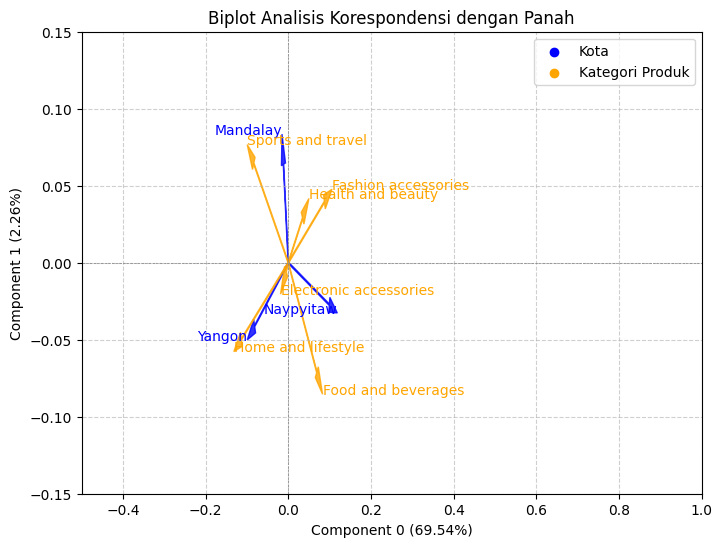

In [23]:
# Gambar biplot
plt.figure(figsize=(8, 6))

# Plot baris (kota) dengan panah
for i, (x, y) in enumerate(zip(row_coords[0], row_coords[1])):
    plt.arrow(0, 0, x, y, color='blue', head_width=0.01, head_length=0.02, length_includes_head=True, alpha=0.8)
    plt.text(x, y, df.index[i], color='blue', fontsize=10, ha='right')

# Plot kolom (kategori produk) dengan panah (ubah warna menjadi oranye)
for i, (x, y) in enumerate(zip(col_coords[0], col_coords[1])):
    plt.arrow(0, 0, x, y, color='orange', head_width=0.01, head_length=0.02, length_includes_head=True, alpha=0.8)
    plt.text(x, y, df.columns[i], color='orange', fontsize=10, ha='left')

# Menambahkan marker dummy untuk legenda
plt.scatter([], [], color='blue', label='Kota')
plt.scatter([], [], color='orange', label='Kategori Produk')

# Label dan legend
plt.axhline(0, color='gray', linewidth=0.5, linestyle='dashed')  # Garis horizontal
plt.axvline(0, color='gray', linewidth=0.5, linestyle='dashed')  # Garis vertikal
plt.xlabel('Component 0 (69.54%)')
plt.ylabel('Component 1 (2.26%)')
plt.title('Biplot Analisis Korespondensi dengan Panah')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.xlim(-0.5, 1)  # Atur batas sumbu x
plt.ylim(-0.15, 0.15)  # Atur batas sumbu y
plt.show()